# Laboratório 3 - Classificação com Sklearn

## imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
import zipfile
import requests
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
pd.set_option('display.max_columns', None)

## Load e análise

In [2]:
# O dataset 405 está no catálogo do UCI, mas não é importável pelo ucimlrepo.
# Por isso, usamos o arquivo oficial disponibilizado pelo próprio UCI.
url = 'https://archive.ics.uci.edu/static/public/405/motion%2Bcapture%2Bhand%2Bpostures.zip'
response = requests.get(url, timeout=60)
response.raise_for_status()
with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
    with archive.open('Postures.csv') as file:
        X_raw = pd.read_csv(file, na_values='?')
X_raw = X_raw.loc[X_raw['Class'] != 0].reset_index(drop=True)
print(f'Formato original: {X_raw.shape}')
display(X_raw.head())
display(X_raw.dtypes.rename('tipo armazenado').to_frame())

Formato original: (78095, 38)


,Class,User,X0,Y0,Z0,X1,Y1,Z1,X2,Y2,Z2,X3,Y3,Z3,X4,Y4,Z4,X5,Y5,Z5,X6,Y6,Z6,X7,Y7,Z7,X8,Y8,Z8,X9,Y9,Z9,X10,Y10,Z10,X11,Y11,Z11
0,1,0,54.263880,71.466776,-64.807709,76.895635,42.462500,-72.780545,36.621229,81.680557,-52.919272,85.232264,67.749220,-73.684130,59.188576,10.678936,-71.297781,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0,56.527558,72.266609,-61.935252,39.135978,82.538530,-49.596509,79.223743,43.254091,-69.982489,87.450873,68.400808,-70.703991,61.587452,11.779919,-68.827418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,0,55.849928,72.469064,-62.562788,37.988804,82.631347,-50.606259,78.451526,43.567403,-70.658489,86.835388,68.907925,-71.138344,61.686427,11.793440,-68.889316,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,0,55.329647,71.707275,-63.688956,36.561863,81.868749,-52.752784,86.320630,68.214645,-72.228461,61.596157,11.250648,-68.956425,77.387225,42.717833,-72.015146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,0,55.142401,71.435607,-64.177303,36.175818,81.556874,-53.475747,76.986143,42.426849,-72.574743,86.368748,67.901260,-72.444650,61.275402,10.841109,-69.279906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,tipo armazenado
Class,int64
User,int64
X0,float64
Y0,float64
Z0,float64
X1,float64
Y1,float64
Z1,float64
X2,float64
Y2,float64


In [3]:
# Hinselmann, Schiller, Cytology, Biopsy são todos exames que podem ser usados como target, escolhi usar Biopsy
target_col = 'Class'
print('Classes:', sorted(X_raw[target_col].dropna().unique()))
display(X_raw[target_col].value_counts(dropna=False).sort_index().rename('quantidade'))

Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


Class
1    16265
2    14978
3    16344
4    14775
5    15733
Name: quantidade, dtype: int64

## Separar o alvo e prevenção de vazamento

O target que escolhi foi `Biopsy`. `Hinselmann`, `Schiller` e `Citology` são resultados de exames relacionados, não faz sentido manter.
`Dx:*` e `Dx` são diagnósticos posteriores ou diretamente relacionados. Portanto, também removi

In [4]:
target_col = 'Class'
assert target_col in X_raw.columns, f'Coluna {target_col!r} não encontrada.'
exam_cols = []
diagnosis_cols = []
y = pd.to_numeric(X_raw[target_col], errors='coerce')
X = X_raw.drop(columns=[target_col, 'User']).copy()
valid_target = y.notna()
X, y = X.loc[valid_target].copy(), y.loc[valid_target].astype(int)
print('Colunas removidas:', [target_col, 'User'])
print(f'Formato de X: {X.shape}; formato de y: {y.shape}')
display(y.value_counts().rename('quantidade'))

Colunas removidas: ['Class', 'User']
Formato de X: (78095, 36); formato de y: (78095,)


Class
3    16344
1    16265
5    15733
2    14978
4    14775
Name: quantidade, dtype: int64

## Valores ausentes

Análise dos valroes nulos. Imputação será feita mais na frente

In [5]:
X = X.replace('?', np.nan)
X = X.apply(pd.to_numeric, errors='coerce')
missing = X.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame('valores_nulos'))
print('Nulos no target:', y.isna().sum())

,valores_nulos
Y11,78064
Z11,78064
X11,78064
Y10,63343
X10,63343
Z10,63343
Y9,54128
X9,54128
Z9,54128
X8,47532


Nulos no target: 0


## Tipos semânticos

O tipo armazenado no dataset não é suficiente para decidir o tipo semântico. A classificação abaixo usa o significado das variáveis: binárias, contagens/idades inteiras e medidas de tempo numéricas.

In [6]:
binary_cols = []
integer_cols = []
numeric_cols = X.columns.tolist()
classified = binary_cols + integer_cols + numeric_cols
print('Binárias:', binary_cols)
print('Discretas:', integer_cols)
print('Numéricas:', numeric_cols)

Binárias: []
Discretas: []
Numéricas: ['X0', 'Y0', 'Z0', 'X1', 'Y1', 'Z1', 'X2', 'Y2', 'Z2', 'X3', 'Y3', 'Z3', 'X4', 'Y4', 'Z4', 'X5', 'Y5', 'Z5', 'X6', 'Y6', 'Z6', 'X7', 'Y7', 'Z7', 'X8', 'Y8', 'Z8', 'X9', 'Y9', 'Z9', 'X10', 'Y10', 'Z10', 'X11', 'Y11', 'Z11']


## Imputação e normalização

Colunas binárias e discretas imputadas pela moda e  numéricas imputadas pela mediana e normalizadas com `StandardScaler`.

In [7]:
preprocessor = ColumnTransformer(transformers=[
    ('discrete', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('scaler', StandardScaler())]), integer_cols),
    ('continuous', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_cols),
    ('binary', Pipeline([('imputer', SimpleImputer(strategy='most_frequent'))]), binary_cols)
], remainder='drop', verbose_feature_names_out=False)
X_prepared = preprocessor.fit_transform(X)
X_prepared = pd.DataFrame(X_prepared, columns=preprocessor.get_feature_names_out(), index=X.index)
print('Nulos após o pré-processamento:', X_prepared.isna().sum().sum())
display(X_prepared.head())

Nulos após o pré-processamento: 0


,X0,Y0,Z0,X1,Y1,Z1,X2,Y2,Z2,X3,Y3,Z3,X4,Y4,Z4,X5,Y5,Z5,X6,Y6,Z6,X7,Y7,Z7,X8,Y8,Z8,X9,Y9,Z9,X10,Y10,Z10,X11,Y11,Z11
0,0.119819,-0.356847,-1.013412,0.840569,-1.081064,-1.244698,-0.356838,-0.050992,-0.636625,1.087845,-0.346660,-1.188318,0.314872,-1.674519,-1.098364,0.1285,0.143283,-0.035764,0.143485,0.158723,0.004167,0.094111,0.092578,0.01955,0.12388,0.091911,0.033351,0.099331,0.054253,0.014934,0.089785,0.05029,-0.034698,-0.007109,0.006714,0.008751
1,0.189054,-0.336952,-0.929817,-0.322062,-0.090359,-0.577804,0.910908,-0.987710,-1.122477,1.153626,-0.330916,-1.105016,0.386368,-1.648165,-1.029106,0.1285,0.143283,-0.035764,0.143485,0.158723,0.004167,0.094111,0.092578,0.01955,0.12388,0.091911,0.033351,0.099331,0.054253,0.014934,0.089785,0.05029,-0.034698,-0.007109,0.006714,0.008751
2,0.168329,-0.331916,-0.948080,-0.357384,-0.088065,-0.606850,0.887928,-0.980073,-1.141726,1.135377,-0.318664,-1.117157,0.389318,-1.647841,-1.030841,0.1285,0.143283,-0.035764,0.143485,0.158723,0.004167,0.094111,0.092578,0.01955,0.12388,0.091911,0.033351,0.099331,0.054253,0.014934,0.089785,0.05029,-0.034698,-0.007109,0.006714,0.008751
3,0.152416,-0.350865,-0.980854,-0.401320,-0.106917,-0.668595,1.122094,-0.379249,-1.186428,0.387040,-1.711744,-1.056167,0.857266,-0.907597,-1.118476,0.1285,0.143283,-0.035764,0.143485,0.158723,0.004167,0.094111,0.092578,0.01955,0.12388,0.091911,0.033351,0.099331,0.054253,0.014934,0.089785,0.05029,-0.034698,-0.007109,0.006714,0.008751
4,0.146689,-0.357622,-0.995066,-0.413207,-0.114627,-0.689391,0.844322,-1.007876,-1.196288,1.121542,-0.342986,-1.153672,0.377068,-1.670638,-1.041792,0.1285,0.143283,-0.035764,0.143485,0.158723,0.004167,0.094111,0.092578,0.01955,0.12388,0.091911,0.033351,0.099331,0.054253,0.014934,0.089785,0.05029,-0.034698,-0.007109,0.006714,0.008751


## Análise de dimensionalidade com PCA

Escolhemos a quantidade mínima de componentes que explica pelo menos 95% da variância dos dados normalizados.

Features antes do PCA: 36
Componentes para 95% da variância: 30


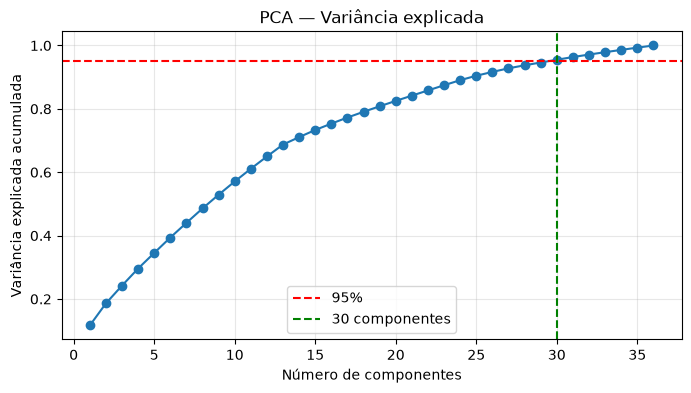

In [8]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_prepared)
cumulative_variance = pca_full.explained_variance_ratio_.cumsum()
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f'Features antes do PCA: {X_prepared.shape[1]}')
print(f'Componentes para 95% da variância: {n_components_95}')
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(.95, color='red', linestyle='--', label='95%')
plt.axvline(n_components_95, color='green', linestyle='--', label=f'{n_components_95} componentes')
plt.xlabel('Número de componentes'); plt.ylabel('Variância explicada acumulada')
plt.title('PCA — Variância explicada'); plt.grid(alpha=.3); plt.legend(); plt.show()

In [9]:
pca = PCA(n_components=n_components_95)
X_reduced = pca.fit_transform(X_prepared)
print(f'Formato após PCA: {X_reduced.shape}')
print(f'Variância explicada: {pca.explained_variance_ratio_.sum():.2%}')

Formato após PCA: (78095, 30)
Variância explicada: 95.50%


## Classificadores

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.base import clone

# Split estratificado para preservar a proporção das classes
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
preprocessor_train = clone(preprocessor) # Aplicar o preprocessamento apenas nos dados de treino para evitar vazamento de dados
X_train = preprocessor_train.fit_transform(X_train_raw)
X_test = preprocessor_train.transform(X_test_raw)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_builders = {
    'Regressão logística': lambda c: LogisticRegression(C=c['C'], max_iter=2000, class_weight='balanced'),
    'SVM': lambda c: SVC(C=c['C'], gamma=c['gamma'], kernel=c['kernel'], class_weight='balanced'),
    'Random Forest': lambda c: RandomForestClassifier(n_estimators=c['n_estimators'], max_depth=c['max_depth'], min_samples_leaf=c['min_samples_leaf'], class_weight='balanced', random_state=42, n_jobs=1),
    'KNN': lambda c: KNeighborsClassifier(n_neighbors=c['n_neighbors'], weights=c['weights'], p=c['p'])
}

import ray
from ray import tune
from ray.air import session

search_spaces = {
    'Regressão logística': {'C': tune.loguniform(1e-3, 1e2)},
    'SVM': {'C': tune.loguniform(1e-3, 1e2), 'gamma': tune.loguniform(1e-4, 1e0), 'kernel': tune.choice(['rbf', 'linear'])},
    'Random Forest': {'n_estimators': tune.choice([100, 200, 400]), 'max_depth': tune.choice([None, 5, 10, 20]), 'min_samples_leaf': tune.choice([1, 2, 4])},
    'KNN': {'n_neighbors': tune.randint(3, 31), 'weights': tune.choice(['uniform', 'distance']), 'p': tune.choice([1, 2])}
}

def trainable(config, X_data, y_data, model_name):
    model = model_builders[model_name](config)
    scores = cross_val_score(model, X_data, y_data, cv=cv, scoring='balanced_accuracy', n_jobs=1)
    session.report({'balanced_accuracy': float(scores.mean()), 'cv_std': float(scores.std())})

ray.init(ignore_reinit_error=True, include_dashboard=False, num_cpus=4)
best_configs, tune_results = {}, {}
for model_name in model_builders:
    tuner = tune.Tuner(
        tune.with_parameters(trainable, X_data=X_train, y_data=y_train.to_numpy(), model_name=model_name),
        param_space=search_spaces[model_name],
        tune_config=tune.TuneConfig(metric='balanced_accuracy', mode='max', num_samples=5),
        run_config=ray.air.RunConfig(name=model_name.replace(' ', '_'))
    )
    result_grid = tuner.fit()
    tune_results[model_name] = result_grid
    best = result_grid.get_best_result(metric='balanced_accuracy', mode='max')
    best_configs[model_name] = best.config
    print(f'{model_name}: CV balanced accuracy = {best.metrics["balanced_accuracy"]:.4f}')
    print('  melhores hiperparâmetros:', best.config)
ray.shutdown()

(trainable pid=2352) c:\Users\atcho\Diretorio\MO809\venv\Lib\site-packages\ray\train\_internal\session.py:801: RayDeprecationWarning: `ray.train.report` should be switched to `ray.tune.report` when running in a function passed to Ray Tune. This will be an error in the future. See this issue for more context: https://github.com/ray-project/ray/issues/49454
(trainable pid=2352)   _log_deprecation_warning(
(trainable pid=14076) c:\Users\atcho\Diretorio\MO809\venv\Lib\site-packages\ray\train\_internal\session.py:801: RayDeprecationWarning: `ray.train.report` should be switched to `ray.tune.report` when running in a function passed to Ray Tune. This will be an error in the future. See this issue for more context: https://github.com/ray-project/ray/issues/49454
(trainable pid=14076)   _log_deprecation_warning(
(trainable pid=19424) c:\Users\atcho\Diretorio\MO809\venv\Lib\site-packages\ray\train\_internal\session.py:801: RayDeprecationWarning: `ray.train.report` should be switched to `ray.tun

KNN: CV balanced accuracy = 0.9577
  melhores hiperparâmetros: {'n_neighbors': 4, 'weights': 'uniform', 'p': 1}


,acurácia,precision,recall
classificador,,,
Regressão logística,0.7627,0.7600,0.7627
SVM,0.7878,0.7855,0.7878
Random Forest,0.9881,0.9881,0.9881
KNN,0.9608,0.9614,0.9608


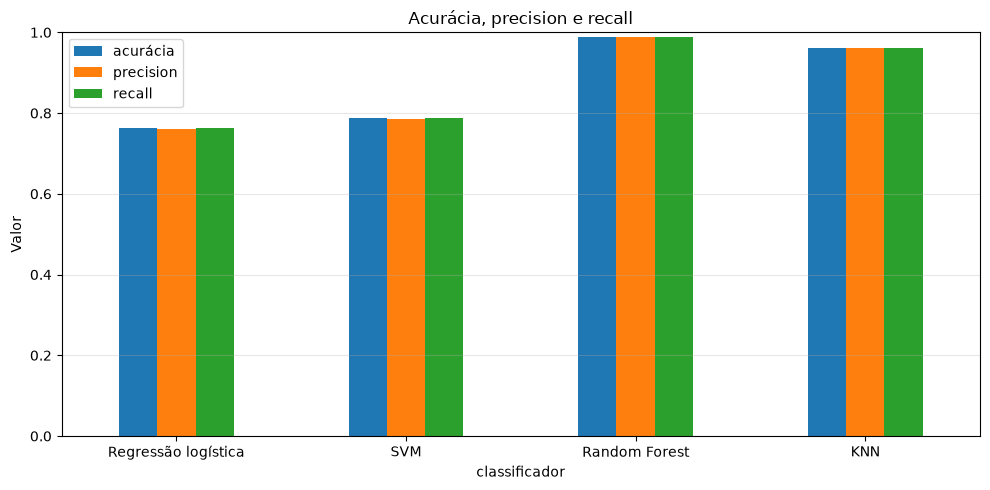

In [11]:
models, predictions, rows = {}, {}, []
for model_name, builder in model_builders.items():
    model = builder(best_configs[model_name])
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    models[model_name], predictions[model_name] = model, prediction
    rows.append({
        'classificador': model_name,
        'acurácia': accuracy_score(y_test, prediction),
        'precision': precision_score(y_test, prediction, average='weighted', zero_division=0),
        'recall': recall_score(y_test, prediction, average='weighted', zero_division=0)
    })
metrics_df = pd.DataFrame(rows).set_index('classificador')
display(metrics_df.round(4))
ax = metrics_df.plot(kind='bar', figsize=(10, 5), ylim=(0, 1), rot=0)
ax.set_ylabel('Valor'); ax.set_title('Acurácia, precision e recall')
ax.grid(axis='y', alpha=.3); plt.tight_layout(); plt.show()

## Métricas no conjunto de teste

Os modelos são treinados com a melhor configuração encontrada e avaliados no conjunto de teste, que não participou da busca.

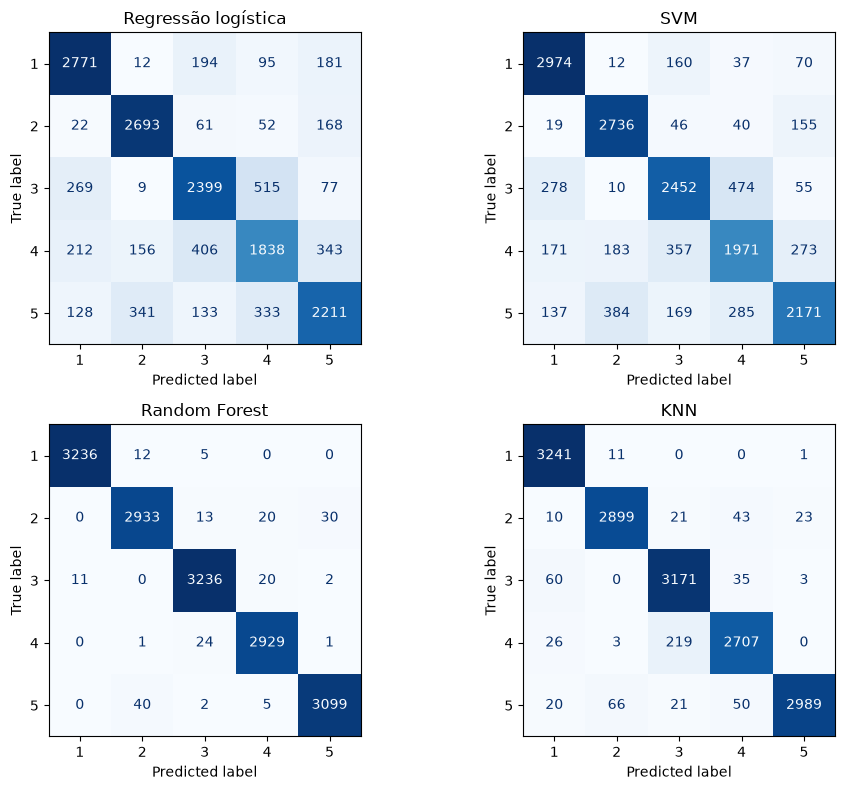

In [12]:
## Matrizes de confusão

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (model_name, prediction) in zip(axes.ravel(), predictions.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, prediction, ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(model_name)
plt.tight_layout(); plt.show()

## Regiões de decisão com PCA em duas dimensões

Os modelos são treinados novamente usando somente as duas primeiras componentes do PCA.

c:\Users\atcho\Diretorio\MO809\venv\Lib\site-packages\mlxtend\plotting\decision_regions.py:352: UserWarning: You passed an edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
c:\Users\atcho\Diretorio\MO809\venv\Lib\site-packages\mlxtend\plotting\decision_regions.py:352: UserWarning: You passed an edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
c:\Users\atcho\Diretorio\MO809\venv\Lib\site-packages\mlxtend\plotting\decision_regions.py:352: UserWarning: You passed an edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
c:\Users\atcho\Diretorio\MO809\venv\Lib\site-packages\mlxtend\plotting\decision_regions.

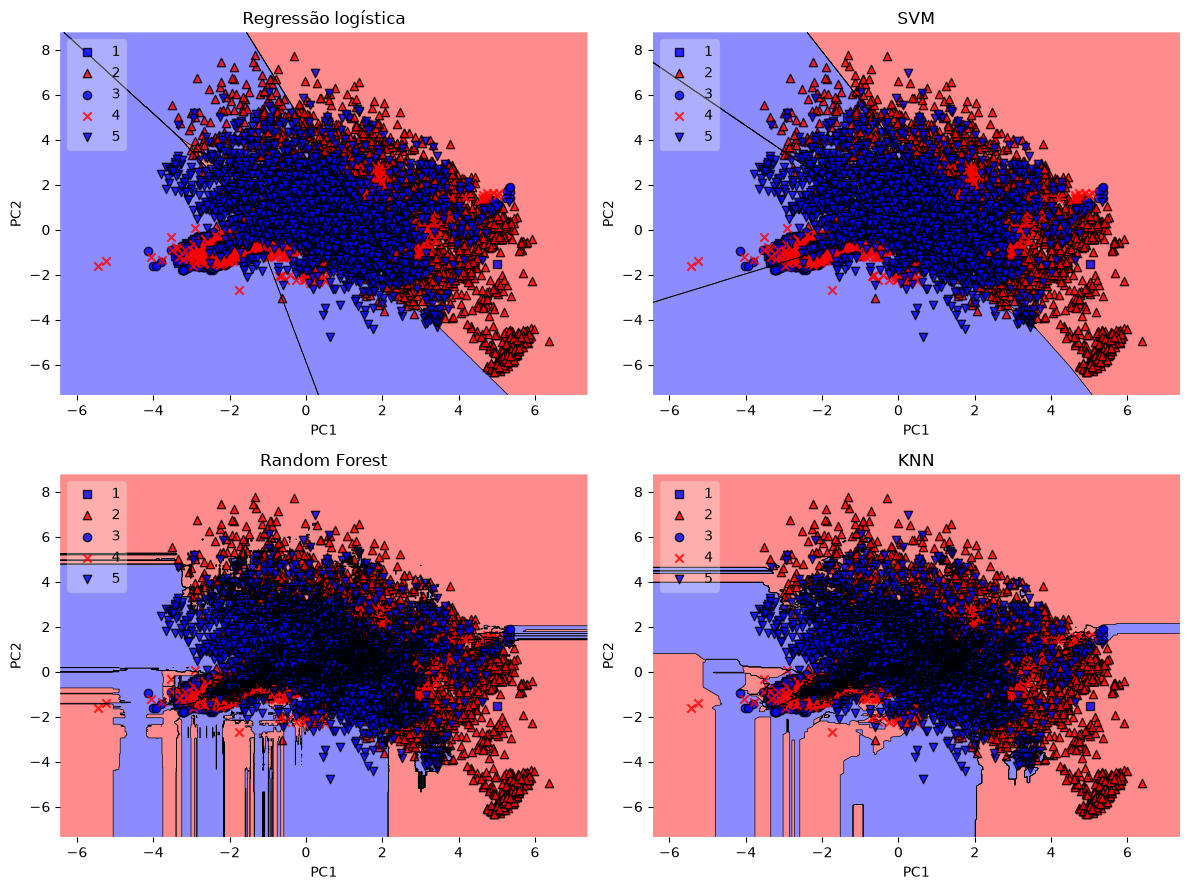

In [13]:
from mlxtend.plotting import plot_decision_regions

pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train)
X_test_2d = pca_2d.transform(X_test)
models_2d = {}
for model_name, builder in model_builders.items():
    model_2d = builder(best_configs[model_name])
    model_2d.fit(X_train_2d, y_train)
    models_2d[model_name] = model_2d

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (model_name, model_2d) in zip(axes.ravel(), models_2d.items()):
    plot_decision_regions(X_test_2d, y_test.to_numpy(), clf=model_2d, legend=2, ax=ax, colors='blue,red')
    ax.set_title(model_name)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout(); plt.show()